# Association Skin Care Product Analysis

Project ini menggunakan metode **Association Rule Mining** untuk menemukan hubungan antar karakteristik produk skin care, seperti kategori harga, rating, jumlah vote, dan jenis produk yang muncul pada judul produk.

Framework yang digunakan adalah **CRISP-DM**:
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment


## 1. Business Understanding

Industri skin care memiliki banyak produk dengan karakteristik yang berbeda, seperti harga, rating, popularitas, dan jenis produk. Dengan menggunakan metode association, data produk dapat dianalisis untuk menemukan pola keterkaitan antar karakteristik produk.

Tujuan project ini adalah menemukan aturan asosiasi dari dataset skin care, misalnya hubungan antara kategori harga, kategori rating, tingkat popularitas vote, dan jenis produk tertentu. Hasil analisis ini dapat digunakan untuk memahami pola umum produk skin care dan membantu proses pengambilan keputusan dalam pemasaran atau rekomendasi produk.


##  Import Library

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import itertools
from collections import Counter

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", None)


## 2. Data Understanding

Pada tahap ini dataset dibaca, kemudian dilakukan pengecekan jumlah data, atribut, tipe data, missing value, data duplikat, dan statistik deskriptif.


In [2]:
# Load dataset
DATA_PATH = Path("skin_care.csv")

# Alternatif jika notebook dijalankan dari folder /mnt/data
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/skin_care.csv")

df = pd.read_csv(DATA_PATH)

print("Jumlah data awal:", df.shape)
df.head()


Jumlah data awal: (3244, 5)


,Unnamed: 0,price,title,stars,vote
0,0,6000,BeautyBio Rose Quartz Roller,4.7,75
1,1,2800,Kopari Starry Eye Balm,4.0,11
2,2,7200,StriVectin SuperC Brighten and Correct Serum,4.6,271
3,3,5900,Skin Gym Rose Quartz Facial Workout Set Nordstrom Exclusive USD 92 Value,5.0,1
4,4,9150,Slip Marble and Charcoal Pillowcase and Sleep Mask Set USD 139 Value,5.0,2


In [3]:
# Informasi struktur dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3244 entries, 0 to 3243
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  3244 non-null   int64  
 1   price       3244 non-null   int64  
 2   title       3244 non-null   object 
 3   stars       3244 non-null   float64
 4   vote        3244 non-null   int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 126.8+ KB


In [21]:
# Missing value dan data duplikat
print("Missing value:")
display(df.isnull().sum())

print("\nJumlah data duplikat:", df.duplicated().sum())


Missing value:


Unnamed: 0    0
price         0
title         0
stars         0
vote          0
dtype: int64


Jumlah data duplikat: 0


In [5]:
# Statistik deskriptif
df.describe()


,Unnamed: 0,price,stars,vote
count,3244.000000,3.244000e+03,3244.000000,3244.000000
mean,1621.500000,4.495740e+04,3.551418,80.162145
std,936.606463,6.421733e+04,1.830841,392.348852
min,0.000000,6.000000e+02,0.000000,0.000000
25%,810.750000,1.537000e+04,3.500000,1.000000
50%,1621.500000,2.629200e+04,4.400000,11.000000
75%,2432.250000,5.055100e+04,4.700000,55.000000
max,3243.000000,1.546868e+06,5.000000,13221.000000


## 3. Data Preparation

Tahap data preparation dilakukan dengan membersihkan kolom yang tidak diperlukan, mengubah tipe data numerik, menghapus missing value, menghapus duplikat, dan membuat kategori untuk keperluan association rule mining.

Kolom yang digunakan:
- `price`
- `title`
- `stars`
- `vote`


In [6]:
# Menghapus kolom index bawaan jika ada
data = df.drop(columns=[col for col in df.columns if col.startswith("Unnamed")], errors="ignore").copy()

# Memastikan kolom numerik sudah sesuai
numeric_cols = ["price", "stars", "vote"]
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Menghapus missing value dan duplikat
data = data.dropna(subset=["title", "price", "stars", "vote"])
data = data.drop_duplicates()

print("Jumlah data setelah cleaning:", data.shape)
data.head()


Jumlah data setelah cleaning: (3240, 4)


,price,title,stars,vote
0,6000,BeautyBio Rose Quartz Roller,4.7,75
1,2800,Kopari Starry Eye Balm,4.0,11
2,7200,StriVectin SuperC Brighten and Correct Serum,4.6,271
3,5900,Skin Gym Rose Quartz Facial Workout Set Nordstrom Exclusive USD 92 Value,5.0,1
4,9150,Slip Marble and Charcoal Pillowcase and Sleep Mask Set USD 139 Value,5.0,2


In [7]:
# Membuat kategori harga
data["Price_Category"] = pd.qcut(
    data["price"],
    q=3,
    labels=["Harga_Rendah", "Harga_Sedang", "Harga_Tinggi"],
    duplicates="drop"
).astype(str)

# Membuat kategori rating
data["Rating_Category"] = pd.cut(
    data["stars"],
    bins=[-np.inf, 3.99, 4.49, np.inf],
    labels=["Rating_Rendah", "Rating_Sedang", "Rating_Tinggi"]
).astype(str)

# Membuat kategori vote/popularitas
# Rank digunakan supaya pembagian qcut tetap stabil walaupun ada nilai vote yang sama.
data["Vote_Category"] = pd.qcut(
    data["vote"].rank(method="first"),
    q=3,
    labels=["Vote_Rendah", "Vote_Sedang", "Vote_Tinggi"],
    duplicates="drop"
).astype(str)

data[["price", "Price_Category", "stars", "Rating_Category", "vote", "Vote_Category"]].head()


,price,Price_Category,stars,Rating_Category,vote,Vote_Category
0,6000,Harga_Rendah,4.7,Rating_Tinggi,75,Vote_Tinggi
1,2800,Harga_Rendah,4.0,Rating_Sedang,11,Vote_Sedang
2,7200,Harga_Rendah,4.6,Rating_Tinggi,271,Vote_Tinggi
3,5900,Harga_Rendah,5.0,Rating_Tinggi,1,Vote_Rendah
4,9150,Harga_Rendah,5.0,Rating_Tinggi,2,Vote_Rendah


In [8]:
# Mengambil jenis produk berdasarkan kata kunci pada judul produk
product_keywords = {
    "Serum": r"\bserum\b",
    "Cream": r"\bcream\b|\bcreme\b",
    "Mask": r"\bmask\b|\bmasque\b",
    "Eye": r"\beye\b|\beyes\b",
    "Cleanser": r"\bcleanser\b|\bcleansing\b|\bwash\b",
    "Moisturizer": r"\bmoisturizer\b|\bmoisturizing\b|\bhydrator\b|\bhydrating\b",
    "Oil": r"\boil\b",
    "Toner": r"\btoner\b",
    "Peel": r"\bpeel\b",
    "Treatment": r"\btreatment\b",
    "Lotion": r"\blotion\b",
    "Balm": r"\bbalm\b",
    "Set": r"\bset\b|\bkit\b",
    "Roller": r"\broller\b",
    "Sunscreen": r"\bsunscreen\b|\bspf\b",
    "Gel": r"\bgel\b",
    "Pillowcase": r"\bpillowcase\b|\bsleep mask\b"
}

def extract_product_items(title):
    title = str(title).lower()
    items = []
    for product, pattern in product_keywords.items():
        if re.search(pattern, title):
            items.append(f"Produk_{product}")
    if len(items) == 0:
        items.append("Produk_Lainnya")
    return items

data["Product_Items"] = data["title"].apply(extract_product_items)

data[["title", "Product_Items", "Price_Category", "Rating_Category", "Vote_Category"]].head(10)


,title,Product_Items,Price_Category,Rating_Category,Vote_Category
0,BeautyBio Rose Quartz Roller,[Produk_Roller],Harga_Rendah,Rating_Tinggi,Vote_Tinggi
1,Kopari Starry Eye Balm,"[Produk_Eye, Produk_Balm]",Harga_Rendah,Rating_Sedang,Vote_Sedang
2,StriVectin SuperC Brighten and Correct Serum,[Produk_Serum],Harga_Rendah,Rating_Tinggi,Vote_Tinggi
3,Skin Gym Rose Quartz Facial Workout Set Nordstrom Exclusive USD 92 Value,[Produk_Set],Harga_Rendah,Rating_Tinggi,Vote_Rendah
4,Slip Marble and Charcoal Pillowcase and Sleep Mask Set USD 139 Value,"[Produk_Mask, Produk_Set, Produk_Pillowcase]",Harga_Rendah,Rating_Tinggi,Vote_Rendah
5,LightStim for Acne LED Light Therapy Device,[Produk_Lainnya],Harga_Rendah,Rating_Sedang,Vote_Sedang
6,Charlotte Tilbury Magic Eye Rescue Cream,"[Produk_Cream, Produk_Eye]",Harga_Rendah,Rating_Rendah,Vote_Tinggi
7,iluminage TOUCH Precision Adaptor,[Produk_Lainnya],Harga_Rendah,Rating_Rendah,Vote_Rendah
8,MZ Skin LightTherapy Golden Facial Treatment Device,[Produk_Treatment],Harga_Tinggi,Rating_Rendah,Vote_Rendah
9,BeautyBio GloPRO LIP MicroTip Attachment Head,[Produk_Lainnya],Harga_Rendah,Rating_Tinggi,Vote_Sedang


In [9]:
# Membuat data transaksi untuk association
transactions = []

for _, row in data.iterrows():
    items = [
        row["Price_Category"],
        row["Rating_Category"],
        row["Vote_Category"]
    ] + row["Product_Items"]

    transactions.append(sorted(set(items)))

print("Jumlah transaksi:", len(transactions))
transactions[:5]


Jumlah transaksi: 3240


[['Harga_Rendah', 'Produk_Roller', 'Rating_Tinggi', 'Vote_Tinggi'],
 ['Harga_Rendah', 'Produk_Balm', 'Produk_Eye', 'Rating_Sedang', 'Vote_Sedang'],
 ['Harga_Rendah', 'Produk_Serum', 'Rating_Tinggi', 'Vote_Tinggi'],
 ['Harga_Rendah', 'Produk_Set', 'Rating_Tinggi', 'Vote_Rendah'],
 ['Harga_Rendah',
  'Produk_Mask',
  'Produk_Pillowcase',
  'Produk_Set',
  'Rating_Tinggi',
  'Vote_Rendah']]

##  Visualisasi Awal

Visualisasi ini digunakan untuk melihat distribusi kategori harga, rating, vote, dan jenis produk yang akan digunakan dalam association.


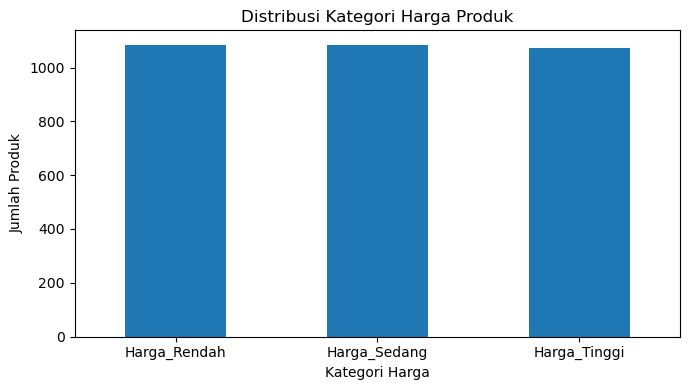

In [10]:
# Visualisasi kategori harga
plt.figure(figsize=(7, 4))
data["Price_Category"].value_counts().plot(kind="bar")
plt.title("Distribusi Kategori Harga Produk")
plt.xlabel("Kategori Harga")
plt.ylabel("Jumlah Produk")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


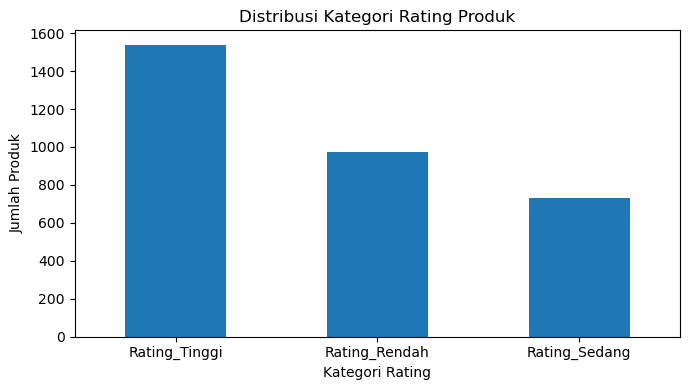

In [11]:
# Visualisasi kategori rating
plt.figure(figsize=(7, 4))
data["Rating_Category"].value_counts().plot(kind="bar")
plt.title("Distribusi Kategori Rating Produk")
plt.xlabel("Kategori Rating")
plt.ylabel("Jumlah Produk")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


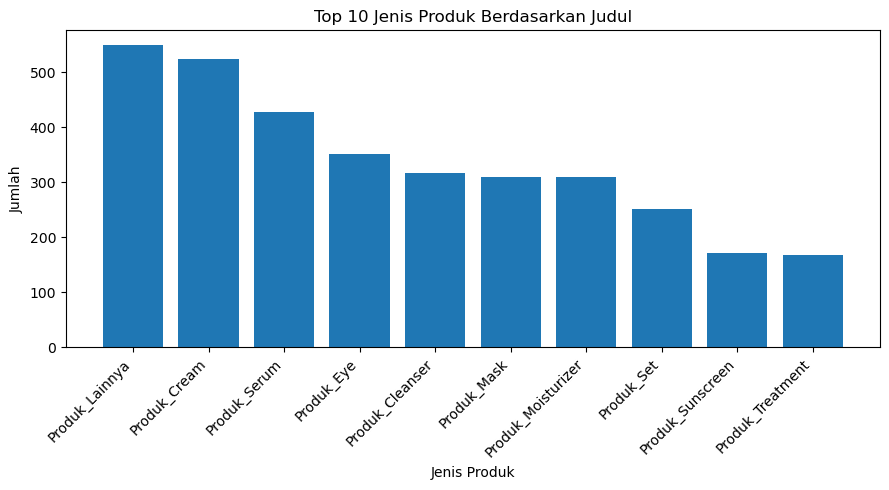

,Jenis_Produk,Jumlah
0,Produk_Lainnya,549
1,Produk_Cream,525
2,Produk_Serum,428
3,Produk_Eye,352
4,Produk_Cleanser,317
5,Produk_Mask,310
6,Produk_Moisturizer,309
7,Produk_Set,251
8,Produk_Sunscreen,172
9,Produk_Treatment,168


In [12]:
# Visualisasi jenis produk berdasarkan kata kunci
product_counter = Counter()

for items in data["Product_Items"]:
    product_counter.update(items)

top_products = pd.DataFrame(
    product_counter.most_common(10),
    columns=["Jenis_Produk", "Jumlah"]
)

plt.figure(figsize=(9, 5))
plt.bar(top_products["Jenis_Produk"], top_products["Jumlah"])
plt.title("Top 10 Jenis Produk Berdasarkan Judul")
plt.xlabel("Jenis Produk")
plt.ylabel("Jumlah")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

top_products


## 4. Modeling

Pada tahap modeling digunakan pendekatan Association Rule Mining. Proses ini menghasilkan:
- **Frequent itemsets**, yaitu kombinasi item yang sering muncul.
- **Association rules**, yaitu aturan hubungan antar item berdasarkan support, confidence, dan lift.

Parameter yang digunakan:
- Minimum support: 0.02
- Minimum confidence: 0.80


In [13]:
def mine_frequent_itemsets(transactions, min_support=0.02, max_len=4):
    n_transactions = len(transactions)
    itemset_counts = Counter()

    for transaction in transactions:
        transaction = sorted(set(transaction))
        for length in range(1, min(max_len, len(transaction)) + 1):
            for combination in itertools.combinations(transaction, length):
                itemset_counts[combination] += 1

    rows = []
    for itemset, count in itemset_counts.items():
        support = count / n_transactions
        if support >= min_support:
            rows.append({
                "itemsets": itemset,
                "support": support,
                "count": count,
                "length": len(itemset)
            })

    result = pd.DataFrame(rows)
    if not result.empty:
        result = result.sort_values(
            ["length", "support", "count"],
            ascending=[True, False, False]
        ).reset_index(drop=True)

    return result


def generate_association_rules(frequent_itemsets, min_confidence=0.80):
    columns = [
        "antecedents", "consequents", "support", "confidence", "lift",
        "antecedent_support", "consequent_support"
    ]

    if frequent_itemsets.empty:
        return pd.DataFrame(columns=columns)

    support_dict = {
        tuple(row.itemsets): row.support
        for row in frequent_itemsets.itertuples(index=False)
    }

    rules = []

    for itemset, support in support_dict.items():
        if len(itemset) < 2:
            continue

        itemset_set = set(itemset)

        for length in range(1, len(itemset)):
            for antecedent in itertools.combinations(itemset, length):
                antecedent = tuple(sorted(antecedent))
                consequent = tuple(sorted(itemset_set - set(antecedent)))

                if antecedent in support_dict and consequent in support_dict:
                    confidence = support / support_dict[antecedent]
                    lift = confidence / support_dict[consequent]

                    if confidence >= min_confidence:
                        rules.append({
                            "antecedents": antecedent,
                            "consequents": consequent,
                            "support": support,
                            "confidence": confidence,
                            "lift": lift,
                            "antecedent_support": support_dict[antecedent],
                            "consequent_support": support_dict[consequent]
                        })

    result = pd.DataFrame(rules, columns=columns)
    if not result.empty:
        result = result.sort_values(
            ["confidence", "lift", "support"],
            ascending=[False, False, False]
        ).reset_index(drop=True)

    return result


In [14]:
# Menjalankan proses frequent itemsets dan association rules
min_support = 0.02
min_confidence = 0.80

frequent_itemsets = mine_frequent_itemsets(
    transactions,
    min_support=min_support,
    max_len=4
)

rules = generate_association_rules(
    frequent_itemsets,
    min_confidence=min_confidence
)

print("Jumlah frequent itemsets:", len(frequent_itemsets))
print("Jumlah association rules:", len(rules))


Jumlah frequent itemsets: 192
Jumlah association rules: 5


In [15]:
# Menampilkan frequent itemsets
frequent_display = frequent_itemsets.copy()
frequent_display["itemsets"] = frequent_display["itemsets"].apply(lambda x: ", ".join(x))
frequent_display.head(20)


,itemsets,support,count,length
0,Rating_Tinggi,0.474691,1538,1
1,Harga_Rendah,0.334568,1084,1
2,Harga_Sedang,0.334568,1084,1
3,Vote_Tinggi,0.333333,1080,1
4,Vote_Sedang,0.333333,1080,1
5,Vote_Rendah,0.333333,1080,1
6,Harga_Tinggi,0.330864,1072,1
7,Rating_Rendah,0.299691,971,1
8,Rating_Sedang,0.225617,731,1
9,Produk_Lainnya,0.169444,549,1


In [16]:
# Menampilkan association rules
rules_display = rules.copy()
rules_display["antecedents"] = rules_display["antecedents"].apply(lambda x: ", ".join(x))
rules_display["consequents"] = rules_display["consequents"].apply(lambda x: ", ".join(x))
rules_display.head(20)


,antecedents,consequents,support,confidence,lift,antecedent_support,consequent_support
0,"Harga_Tinggi, Produk_Set, Rating_Rendah",Vote_Rendah,0.021605,0.945946,2.837838,0.022840,0.333333
1,"Produk_Set, Rating_Rendah",Vote_Rendah,0.041667,0.924658,2.773973,0.045062,0.333333
2,"Harga_Tinggi, Produk_Set",Vote_Rendah,0.026543,0.843137,2.529412,0.031481,0.333333
3,"Produk_Mask, Rating_Rendah",Vote_Rendah,0.025309,0.820000,2.460000,0.030864,0.333333
4,"Harga_Tinggi, Produk_Set, Vote_Rendah",Rating_Rendah,0.021605,0.813953,2.715973,0.026543,0.299691


In [22]:
# Menyimpan hasil ke file CSV
frequent_display.to_csv("frequent_itemsets.csv", index=False)
rules_display.to_csv("association_rules.csv", index=False)

print("File frequent_itemsets.csv dan association_rules.csv berhasil dibuat.")


File frequent_itemsets.csv dan association_rules.csv berhasil dibuat.


## 5. Evaluation

Evaluasi association dilakukan menggunakan:
- **Support**: seberapa sering kombinasi item muncul.
- **Confidence**: tingkat kepercayaan hubungan antar item.
- **Lift**: kekuatan hubungan antar item dibandingkan kemunculan acak.

Kriteria sukses project ini adalah minimal confidence sebesar 80%.


In [18]:
if len(rules) > 0:
    max_confidence = rules["confidence"].max()
    avg_confidence = rules["confidence"].mean()
    max_lift = rules["lift"].max()
    avg_lift = rules["lift"].mean()

    print("Evaluasi Association")
    print("--------------------")
    print(f"Jumlah transaksi        : {len(transactions)}")
    print(f"Jumlah frequent itemsets: {len(frequent_itemsets)}")
    print(f"Jumlah association rules: {len(rules)}")
    print(f"Confidence tertinggi    : {max_confidence:.2%}")
    print(f"Rata-rata confidence    : {avg_confidence:.2%}")
    print(f"Lift tertinggi          : {max_lift:.2f}")
    print(f"Rata-rata lift          : {avg_lift:.2f}")

    if max_confidence >= 0.80:
        print("Kesimpulan evaluasi     : Memenuhi kriteria sukses minimal confidence 80%.")
    else:
        print("Kesimpulan evaluasi     : Belum memenuhi kriteria sukses minimal confidence 80%.")
else:
    print("Tidak ada rules yang memenuhi parameter support dan confidence.")


Evaluasi Association
--------------------
Jumlah transaksi        : 3240
Jumlah frequent itemsets: 192
Jumlah association rules: 5
Confidence tertinggi    : 94.59%
Rata-rata confidence    : 86.95%
Lift tertinggi          : 2.84
Rata-rata lift          : 2.66
Kesimpulan evaluasi     : Memenuhi kriteria sukses minimal confidence 80%.


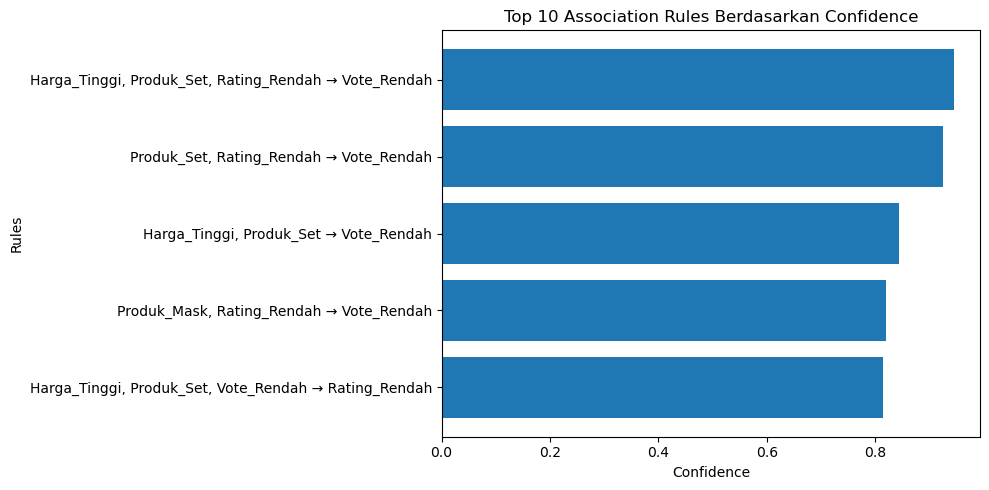

In [19]:
# Visualisasi top rules berdasarkan confidence
if len(rules_display) > 0:
    top_rules = rules_display.head(10).copy()
    top_rules["rule"] = top_rules["antecedents"] + " → " + top_rules["consequents"]

    plt.figure(figsize=(10, 5))
    plt.barh(top_rules["rule"], top_rules["confidence"])
    plt.title("Top 10 Association Rules Berdasarkan Confidence")
    plt.xlabel("Confidence")
    plt.ylabel("Rules")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada rules untuk divisualisasikan.")


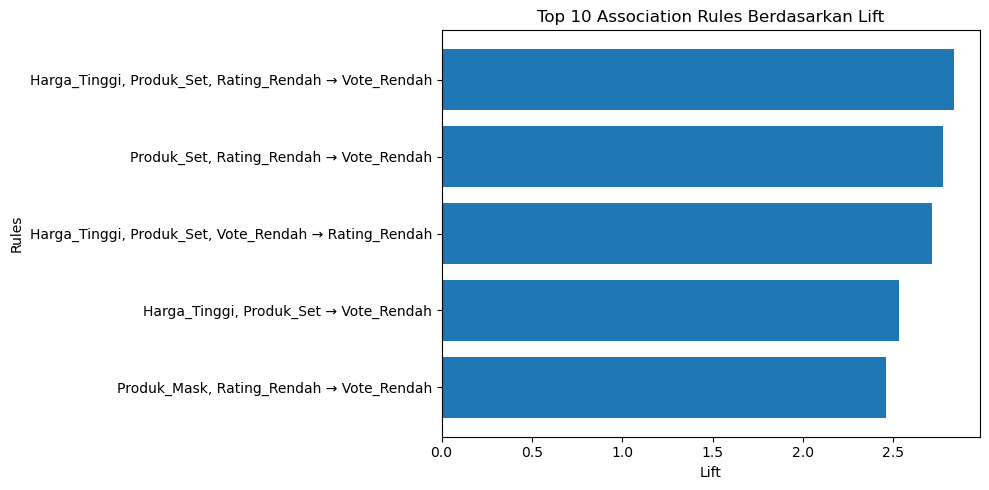

In [20]:
# Visualisasi top rules berdasarkan lift
if len(rules_display) > 0:
    top_lift = rules_display.sort_values("lift", ascending=False).head(10).copy()
    top_lift["rule"] = top_lift["antecedents"] + " → " + top_lift["consequents"]

    plt.figure(figsize=(10, 5))
    plt.barh(top_lift["rule"], top_lift["lift"])
    plt.title("Top 10 Association Rules Berdasarkan Lift")
    plt.xlabel("Lift")
    plt.ylabel("Rules")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada rules untuk divisualisasikan.")


## 6. Deployment

Hasil project ini dapat dipublikasikan dalam bentuk Google Sites. Konten yang ditampilkan meliputi judul project, identitas mahasiswa, deskripsi studi kasus, tahapan CRISP-DM, visualisasi hasil analisis, screenshot coding, dan kesimpulan.


## 7. Kesimpulan

Project Association pada dataset Skin Care menghasilkan pola hubungan antar kategori produk, harga, rating, dan vote. Dari hasil association rule mining, diperoleh frequent itemsets dan association rules yang dapat digunakan untuk melihat karakteristik produk yang sering muncul secara bersamaan.

Association rules dievaluasi menggunakan support, confidence, dan lift. Rule dengan confidence tinggi menunjukkan hubungan yang kuat antara antecedent dan consequent. Jika confidence tertinggi mencapai minimal 80%, maka project ini memenuhi kriteria sukses evaluasi.
